In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from promis import ProMis, DeltaStaRMap
from promis.geo import DeltaGrid, PolarLocation
from promis.loaders import OsmLoader

In [3]:
origin = PolarLocation(latitude=49.876882, longitude=8.650317)
width, height = 80.0, 80.0

support = DeltaGrid(origin, (20, 20), width, height)
DeltaGrid(origin, (2,2), 10, 10, bearing_res=3, speed_res=2).data.head(13)

,east,north,bearing,speed,v0
0,-5.0,-5.0,0.0,30.0,0.0
1,5.0,-5.0,0.0,30.0,0.0
2,-5.0,5.0,0.0,30.0,0.0
3,5.0,5.0,0.0,30.0,0.0
4,-5.0,-5.0,180.0,30.0,0.0
5,5.0,-5.0,180.0,30.0,0.0
6,-5.0,5.0,180.0,30.0,0.0
7,5.0,5.0,180.0,30.0,0.0
8,-5.0,-5.0,360.0,30.0,0.0
9,5.0,-5.0,360.0,30.0,0.0


In [4]:
feature_description = {
    "secondary": "['highway' = 'secondary']",
    "service": "['highway' = 'service']",
    "residential": "['highway' = 'residential']",
    "crossing": "['footway' = 'crossing']",
    "living_street": "[highway=living_street]",
    "signal": "['highway' = 'traffic_signals']",
}
covariance = {
    "secondary":    1.5 * np.eye(2),
    "residential":  2 * np.eye(2),
    "crossing":     2 * np.eye(2),
}
logic = """
    
    on_road(X) :-
        over(X, residential);
        over(X, secondary).

    respects_walkers(X) :- 
        \+ crosses(X, crossing).

    % Definition of a valid mission
    landscape(X) :-
        on_road(X),
        respects_walkers(X).

    % Also compute for debug purposes:
    over(X, crossing). 
"""

In [5]:
print("build uam")
uam = OsmLoader(origin, (width, height), feature_description, polygonize_routes=True).to_cartesian_map()
uam.apply_covariance(covariance)

print("build dsm")
dsm = DeltaStaRMap(uam)
dsm.initialize(support, 15, logic)

build uam
OSM query failed, sleeping 5.0s...
build dsm
[[-40.         -40.           0.          30.        ]
 [-35.78947368 -40.           0.          30.        ]
 [-31.57894737 -40.           0.          30.        ]
 ...
 [ 31.57894737  40.         360.          70.        ]
 [ 35.78947368  40.         360.          70.        ]
 [ 40.          40.         360.          70.        ]]


interpolator called in <promis.geo.delta_collection.CartesianDeltaCollection object at 0x7415fdd54670>
interpolator called in <promis.geo.delta_collection.CartesianDeltaCollection object at 0x7415fdd54670>
interpolator called in <promis.geo.delta_collection.CartesianDeltaCollection object at 0x7415fda032e0>
interpolator called in <promis.geo.delta_collection.CartesianDeltaCollection object at 0x7415fda032e0>


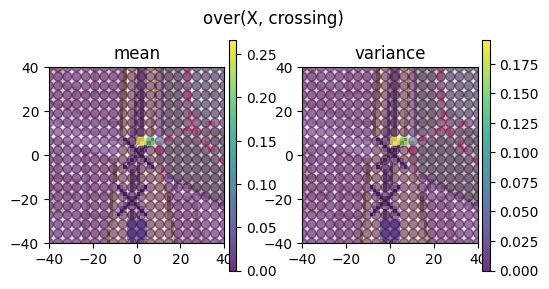

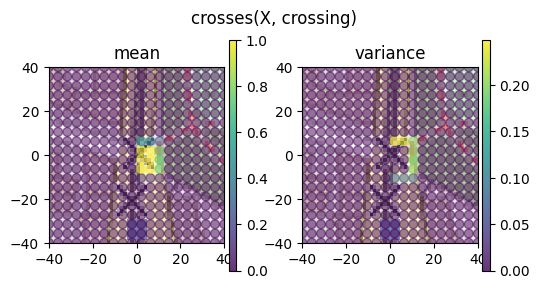

In [6]:
def plot_relation(starmap, relation_name, location_type) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    fig.suptitle(f"{relation_name}(X, {location_type})")
    relation = starmap.get(relation_name, location_type).parameters
    for i, label in enumerate(["mean", "variance"]):
        img = relation.scatter(i, bearing = 0, speed = 50, s = 40, alpha = 0.5, ax = axes[i])
        cbar = plt.colorbar(img, aspect=30, pad=0.02)
        cbar.solids.set(alpha=0.8)
        axes[i].set_title(label)

plot_relation(dsm, "over", "crossing")
plot_relation(dsm, "crosses", "crossing")

In [7]:
promis = ProMis(dsm)
target = DeltaGrid(origin, (40, 40), width, height, speed_res=3)
landscape = promis.solve(target, logic, batch_size=5, show_progress=True, print_first=True)

interpolator called in <promis.geo.delta_collection.CartesianDeltaCollection object at 0x7415fd76d4e0>
interpolator called in <promis.geo.delta_collection.CartesianDeltaCollection object at 0x7416000dff10>
interpolator called in <promis.geo.delta_collection.CartesianDeltaCollection object at 0x7415fdb1c160>
interpolator called in <promis.geo.delta_collection.CartesianDeltaCollection object at 0x7415fdb1c3d0>

    
    on_road(X) :-
        over(X, residential);
        over(X, secondary).

    respects_walkers(X) :- 
        \+ crosses(X, crossing).

    % Definition of a valid mission
    landscape(X) :-
        on_road(X),
        respects_walkers(X).

    % Also compute for debug purposes:
    over(X, crossing). 

0.0::over(x_0, secondary).
0.0::over(x_0, residential).
0.0::over(x_0, crossing).
0.0::crosses(x_0, crossing).
state_east(x_0, -40.0).
state_north(x_0, -40.0).
state_bearing(x_0, 0.0).
state_speed(x_0, 30.0).
query(landscape(x_0)).
0.0::over(x_1, secondary).
0.0::over(x_1,

/home/julius/Documents/ba_inf_6/bachelorarbeit/ProMis/.venv/lib/python3.10/site-packages/promis/promis.py:202: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f"state_{evaluation_points.data.columns[i]}(x_{index}, {state[i]})."


Output()

interpolator called in <promis.geo.delta_grid.DeltaGrid object at 0x7415fd786ef0>
interpolator called in <promis.geo.delta_collection.CartesianDeltaCollection object at 0x7415f40f6950>


[None]

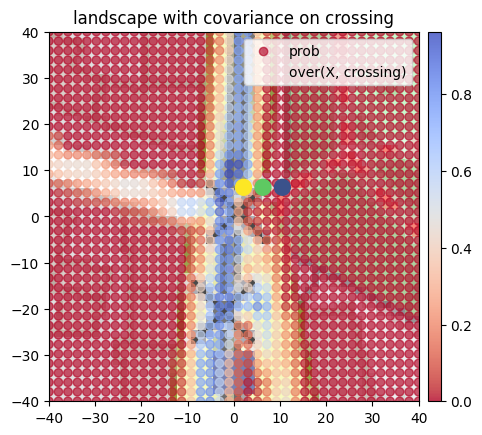

In [24]:
fig, ax = plt.subplots()
b, s = 0, 30
img = target.scatter(bearing=b, speed = s, cmap = "coolwarm_r", alpha = 0.65, plot_basemap=True, ax=ax, label="prob")
crossings = dsm.get("over", "crossing").parameters
crossings.scatter(bearing = b, speed=s, ax = ax, plot_basemap=False, s = 130, alpha=crossings.values_for(b, s)[:, 0] > 0.05, label="over(X, crossing)")
cbar = plt.colorbar(img, aspect=30, pad=0.02)
legend = plt.legend(loc=1)
plt.title("landscape with covariance on crossing")
cbar.solids.set(alpha=0.8)